In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import animation

In [2]:
%matplotlib ipympl

In [3]:
plt.rcParams["figure.figsize"] = [6, 2.5]

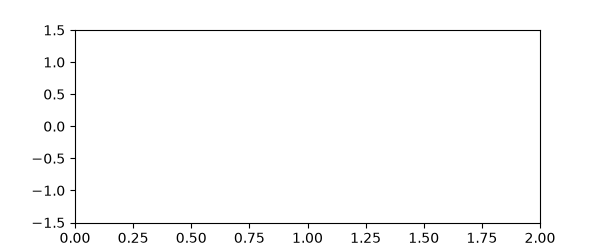

In [4]:
figure1 = plt.figure()

ax1 = plt.axes(xlim=(0, 2), ylim=(-1.5, 1.5))
line1, = ax1.plot([], [], linewidth=2)
speed = 1
offset = 0.

def compute_and_display(n):
    global offset
    offset += speed / 100
    x = np.linspace(0, 2, 100)
    y = np.sin(2 * np.pi * (x - offset))
    line1.set_data(x, y)
    return line1

anim = animation.FuncAnimation(figure1, 
                               func=compute_and_display, 
                               frames=50,
                               repeat=False, 
                               interval=40, 
                               blit=True)

plt.show()

/var/folders/8s/q4htv1115d70bm1_gqh1mswc0000gn/T/ipykernel_16318/2846721885.py:21: UserWarning: frames=<generator object compute at 0x10dc95240> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim = animation.FuncAnimation(figure2,


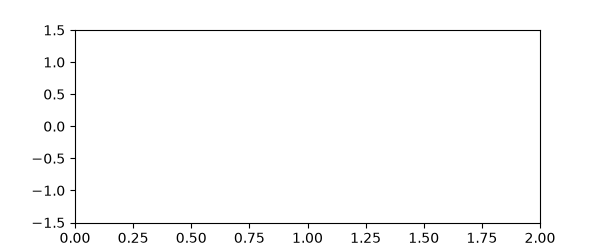

In [5]:
figure2 = plt.figure()
ax2 = plt.axes(xlim=(0, 2), ylim=(-1.5, 1.5))
line2, = ax2.plot([], [], linewidth=2, color='m')

speed = 1

def compute():
    offset = 0

    for _ in range(50):
        offset += speed / 100
        x = np.linspace(0, 2, 1000)
        y = np.sin(2 * np.pi * (x - offset))
        yield x, y

def display(frame):
    x, y = frame
    line2.set_data(x, y)
    return line2

anim = animation.FuncAnimation(figure2, 
                               func=display, 
                               frames=compute(), 
                               repeat=False, 
                               interval=40, 
                               blit=True)

plt.show()

## Rendre intéractif avec un widget

In [6]:
from IPython.display import display as display_widget
from ipywidgets import IntSlider

IntSlider(value=3, description='Vitesse:', max=10, min=1)

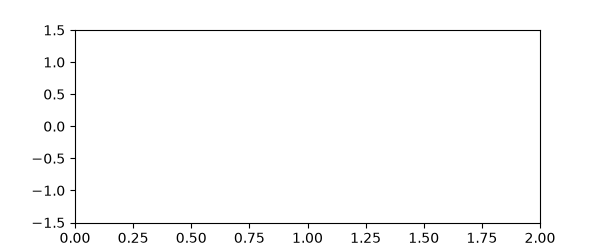

In [7]:
figure3 = plt.figure()
ax3 = plt.axes(xlim=(0, 2), ylim=(-1.5, 1.5))
line3, = ax3.plot([], [], linewidth=2)

speed_slider = IntSlider(min=1, max=10, value=3,
                         description="Vitesse:")

def compute():
    offset = 0.
    while True:
        offset += speed_slider.value / 100
        x = np.linspace(0, 2, 1000)
        y = np.sin(2 * np.pi * (x - offset))
        yield x, y

def display(frame):
    x, y = frame
    line3.set_data(x, y)
    return line3,

anim = animation.FuncAnimation(figure3,
                               func=display,
                               frames=compute(),
                               interval=40, blit=True,
                               cache_frame_data=False)

display_widget(speed_slider)
plt.show()

On peut avoir l'impression que 3 choses ont lieu principalement en même temps:

- la logique de calcul, qui en substance est décrite comme un unique `while True:`,

- la logique d'affichage, qui est cadencée par FuncAnimation,

- et la logique interactive, qui gère le widget sur interaction de l'utilisateur.

Grâce à la fois au générateur et au notebook, on n'a pas du tout besoin de gérer soi-même cet aspect de programmation parallèle.